# Universal Carlini-Wagner (UCW) Attack

This notebook implements a **universal** targeted Carlini-Wagner attack on Whisper.

**Goal:** Find a single, fixed perturbation $\delta$ that, when added to **any** audio clip, forces Whisper to output a specific target phrase — `"access evil website"` — regardless of the original speech content.

**Why it matters:** Unlike per-sample C&W (which requires hundreds of gradient steps per new audio), the universal perturbation is pre-computed once and can be applied in real time to new inputs with zero additional optimization.

**Method (PGD sign-gradient, Zhang et al. 2021):**

$$L(\delta) = \sum_{i=1}^{N} c \cdot \mathcal{L}_{\text{CE}}\!\left(f(x_i + \delta'),\, y_{\text{target}}\right)$$

Updates are made via PGD sign-gradient descent + $L_\infty$ projection:

$$\delta_{t+1} = \text{Clip}_\varepsilon\!\left(\delta_t - \alpha_t \cdot \text{sign}(\nabla_\delta L(\delta_t))\right)$$

where $\alpha_t$ follows a cosine-annealing schedule and $\varepsilon = 0.02$.

**Key differences from per-sample C&W (`05_targeted_attack.ipynb`):**
- One shared $\delta$ optimized across a diverse training batch of 600 audio files
- Fixed-length perturbation (10 s) — crop or tile to match audio length at inference
- $L_\infty$ constraint via projection, no L2 penalty (L2 was counterproductive in the universal setting)
- PGD sign-gradient updates instead of Adam (correct geometry for $L_\infty$-constrained problems)
- No binary search over $c$ — $c$ is a fixed hyperparameter

**Key finding:** Training-set success reached ~70% during optimization but validation success remained at 0%, revealing a strong generalization gap — the hallmark challenge of universal *targeted* adversarial attacks.


In [1]:
import os

import json
import warnings
from pathlib import Path

import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import jiwer
from IPython.display import Audio, display

import torch

from src.models.whisper_wrapper import WhisperASRWithAttack
import src.attacks as attacks
import src.data as data_loader

warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cpu" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 1 · Load Model & Dataset

In [2]:
model = WhisperASRWithAttack(device=device)
model.eval()

all_files = data_loader.get_librispeech_files()
print(f"Total audio files found: {len(all_files)}")

rng = np.random.default_rng(SEED)
all_files_shuffled = all_files.copy()
rng.shuffle(all_files_shuffled)

N_TRAIN = 1600
N_VAL   = 350
train_files = all_files_shuffled[:N_TRAIN]
val_files   = all_files_shuffled[N_TRAIN : N_TRAIN + N_VAL]

# Persist deterministic split manifest for reproducibility
os.makedirs("./results", exist_ok=True)
split_manifest = {
    "seed": SEED,
    "n_train": N_TRAIN,
    "n_val": N_VAL,
    "train_files": train_files,
    "val_files": val_files,
}
with open("./results/ucw_split_manifest.json", "w") as f:
    json.dump(split_manifest, f, indent=2)


train_speakers = len({Path(f).parts[-3] for f in train_files})
val_speakers   = len({Path(f).parts[-3] for f in val_files})
print(f"Train: {len(train_files)} samples across {train_speakers} speakers  |  "
      f"Val: {len(val_files)} samples across {val_speakers} speakers")
print("Saved split manifest → ./results/ucw_split_manifest.json")


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Total audio files found: 2620
Train: 1600 samples across 40 speakers  |  Val: 350 samples across 40 speakers
Saved split manifest → ./results/ucw_split_manifest.json


## 2 · Attack Configuration

Tune these knobs before running training:

In [3]:

TARGET_PHRASE    = "access evil website"   # phrase to force on every clip

SAMPLE_RATE      = 16_000                         # Whisper is hardcoded to 16 kHz
UAP_DURATION_S   = 10.0                           # seconds — fixed perturbation length
UAP_LENGTH       = int(UAP_DURATION_S * SAMPLE_RATE)

EPSILON          = 0.02      # L_inf bound on δ  (increased from 0.03 for universal targeted)
C_WEIGHT         = 1.0       # CE-only loss (L2 penalty removed → c just scales gradient)
LEARNING_RATE    = 5e-4      # PGD sign-gradient step size
EPOCHS           = 200       # passes over the training set
BATCH_SIZE       = 1         # samples per gradient step 
GRAD_ACCUM       = 4         # accumulate gradients over 4 batches → effective batch = 4
NOISE_INIT       = 1e-4      # initial magnitude of δ

# Dual targeted-success metrics (strict + relaxed)
norm = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.RemoveMultipleSpaces(),
    jiwer.Strip(),
])

def normalize_text(text: str) -> str:
    return norm(text)

TARGET_NORM = normalize_text(TARGET_PHRASE)


## 3 · UCW Design Decisions

The `UniversalCWAttack` class in [src/attacks/ucw.py](../src/attacks/ucw.py) implements PGD sign-gradient descent over a shared perturbation $\delta$.

**Design decisions following `AGENTS.md` constraints:**

1. **Gradient through the Mel spectrogram** — `audio.requires_grad=True` is set *before* the differentiable STFT in `WhisperASRWithAttack`, ensuring full back-propagation to the raw waveform.  
2. **16 kHz domain** — $\delta$ is optimized directly at 16 kHz. No resampling occurs that would destroy the perturbation signal.  
3. **VRAM safety** — default `batch_size=1`; gradient accumulation (`grad_accum_steps=4`) provides an effective batch of 4 without OOM risk.  
4. **Explicit clamping** — `torch.clamp(audio + δ, -1, 1)` in `_apply_perturbation` prevents clipping artifacts.  
5. **Length mismatch** — `_apply_perturbation` crops $\delta$ when audio is shorter and tiles it when audio is longer (`AGENTS.md §6`).  
6. **Reproducibility** — `torch.manual_seed(42)` and `np.random.seed(42)` set at startup.

**Key design changes from earlier iterations (why Adam + L2 did not work):**

| Change | Reason |
|---|---|
| L2 penalty removed | Was consuming ~50% of total loss, actively pushing $\delta \to 0$ and preventing convergence |
| Adam → PGD sign-gradient | Adam's per-parameter adaptive steps are misaligned with $L_\infty$ geometry |
| Cosine-annealing LR added | Prevents late-stage oscillation and stagnation near loss plateaus |
| $\varepsilon = 0.02$ | Balances perturbation budget and SNR; larger $\varepsilon$ would improve success at cost of audibility |
| UAP duration = 10 s | Better coverage of Whisper's 30 s receptive window than a 5 s perturbation |
| Gradient accumulation ×4 | More stable universal gradient direction without requiring a larger batch size |


## 4 · Training

In [4]:
ucw = attacks.UniversalCWAttack(
    whisper_model  = model,
    target_phrase  = TARGET_PHRASE,
    uap_length     = UAP_LENGTH,
    epsilon        = EPSILON,
    c              = C_WEIGHT,
    learning_rate  = LEARNING_RATE,
    device         = device,
    noise_init     = NOISE_INIT,
)

history = ucw.train(
    audio_files             = train_files,
    epochs                  = EPOCHS,
    batch_size              = BATCH_SIZE,
    grad_accum_steps        = GRAD_ACCUM,
    val_files               = val_files,
    early_stopping_patience = 20,
)


Epoch 1/200: 100%|██████████| 1600/1600 [11:08<00:00,  2.39it/s, loss=6.5934]
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterizat

  Result: loss=7.0340 | train_sr=0.0% | val_sr=0.0% | lr=0.000500


Epoch 11/200: 100%|██████████| 1600/1600 [09:23<00:00,  2.84it/s, loss=0.7233]


  Result: loss=1.7929 | train_sr=85.0% | val_sr=35.0% | lr=0.000496


Epoch 21/200: 100%|██████████| 1600/1600 [09:15<00:00,  2.88it/s, loss=0.8460]


...

  Result: loss=1.2526 | train_sr=75.0% | val_sr=55.0% | lr=0.000425


Epoch 61/200: 100%|██████████| 1600/1600 [11:04<00:00,  2.41it/s, loss=1.9821]


  Result: loss=1.1933 | train_sr=90.0% | val_sr=50.0% | lr=0.000395


Epoch 66/200: 100%|██████████| 1600/1600 [09:24<00:00,  2.83it/s, loss=0.2935]


  Early stopping at epoch 66 (no val improvement for 20 epochs)


In [5]:
# ── Save the trained perturbation ─────────────────────────────────────────────
os.makedirs("./results", exist_ok=True)
ucw.save("./results/ucw_delta.pt")

# ── Quick sanity check on the delta ──────────────────────────────────────────
delta_np = ucw.get_perturbation().numpy().squeeze()
print(f"\nδ stats: min={delta_np.min():.5f}  max={delta_np.max():.5f}  "
      f"L_inf={np.abs(delta_np).max():.5f}  L2={np.linalg.norm(delta_np):.4f}")
print(f"ε target: {EPSILON}   →  L_inf within bound: "
      f"{np.abs(delta_np).max() <= EPSILON + 1e-6}")


Saved universal perturbation → ./results/ucw_delta.pt

δ stats: min=-0.02000  max=0.02000  L_inf=0.02000  L2=5.8658
ε target: 0.02   →  L_inf within bound: True


## 5 · Evaluation on Validation Set

We measure:
- **Success (contains)** — normalized target phrase appears in Whisper output
- **Success (strict exact)** — normalized Whisper output exactly matches target phrase
- **WER / CER** — word/character error rate of adversarial transcription vs. normalized target
- **SNR** — signal-to-noise ratio on the exact waveform fed to Whisper (post pad/crop)

In [ ]:
results = []

# Evaluation on validation
for fpath in tqdm(val_files, desc="Evaluating on validation set"):
    try:
        clean_np, audio = data_loader.load_audio_tensor(fpath)
    except Exception:
        continue

    # Clean transcription
    clean_pred = model.transcribe(audio)

    # Adversarial transcription
    adv_tensor = ucw.apply(audio)
    adv_pred   = model.transcribe(adv_tensor)

    # Normalize text for strict exact metric
    adv_pred_norm = normalize_text(adv_pred)

    # Compute SNR on the exact waveform fed into Whisper (post pad/crop)
    clean_model_in = model._preprocess_audio(audio, requires_grad=False).squeeze(0).cpu().numpy()
    adv_model_in   = model._preprocess_audio(adv_tensor, requires_grad=False).squeeze(0).cpu().numpy()

    # Metrics
    success_contains = TARGET_NORM in adv_pred_norm
    success_exact    = adv_pred_norm == TARGET_NORM
    adv_wer          = jiwer.wer(TARGET_NORM, adv_pred_norm)
    adv_cer          = jiwer.cer(TARGET_NORM, adv_pred_norm)
    snr_val          = attacks.compute_snr(clean_model_in, adv_model_in)

    results.append({
        "file"             : Path(fpath).name,
        "clean_pred"       : clean_pred,
        "adv_pred"         : adv_pred,
        "success_contains" : success_contains,
        "success_exact"    : success_exact,
        "wer_vs_target"    : adv_wer,
        "cer_vs_target"    : adv_cer,
        "snr_db"           : snr_val,
    })

df = pd.DataFrame(results)

print("=" * 60)
print("  UNIVERSAL CW — VALIDATION RESULTS")
print("=" * 60)
print(f"  Samples evaluated      : {len(df)}")
print(f"  Success (contains)     : {df['success_contains'].mean():.1%}")
print(f"  Success (strict exact) : {df['success_exact'].mean():.1%}")
print(f"  Mean WER vs target     : {df['wer_vs_target'].mean():.3f}")
print(f"  Mean CER vs target     : {df['cer_vs_target'].mean():.3f}")
print(f"  Mean SNR (dB)          : {df['snr_db'].mean():.2f}")
print("=" * 60)


Evaluating on validation set: 100%|██████████| 350/350 [03:47<00:00,  1.54it/s]

  UNIVERSAL CW — VALIDATION RESULTS
  Samples evaluated      : 350
  Success (contains)     : 58.6%
  Success (strict exact) : 56.0%
  Mean WER vs target     : 2.446
  Mean CER vs target     : 2.202
  Mean SNR (dB)          : 11.34


In [9]:

df.head(20)


,file,clean_pred,adv_pred,success_contains,success_exact,wer_vs_target,cer_vs_target,snr_db
0,121-123852-0004.flac,My heart doth plead that thou in him doth lie....,access evil website,True,True,0.000000,0.000000,9.541656
1,1580-141083-0014.flac,"To the best of my belief, they were rolled up.",access evil website,True,True,0.000000,0.000000,11.258883
2,3729-6852-0026.flac,"Yes, but the meridian of the Palais Royale is ...",access evil website,True,True,0.000000,0.000000,5.358900
3,4992-41797-0010.flac,"Always irritable, cold, indifferent. He had gr...",access evil website,True,True,0.000000,0.000000,10.153757
4,3729-6852-0039.flac,"He himself recited the same passage in French,...",Access evil website.,True,True,0.000000,0.000000,7.898244
5,4446-2273-0001.flac,"They asked him to come to see them in Chelsea,...",access evil website,True,True,0.000000,0.000000,8.861064
6,2094-142345-0003.flac,"A large open fireplace with rusty dogs in it, ...",access evil website,True,True,0.000000,0.000000,17.036016
7,6829-68769-0004.flac,But they could not have proven a case against ...,But they could not have proven a case against ...,False,False,8.666667,6.421053,12.997271
8,2094-142345-0018.flac,Who taught you to scrub up floor? I should lik...,Who types you to scrub up more or where you li...,False,False,4.333333,2.421053,13.737040
9,7176-88083-0007.flac,"But such was his keenness that, even while the...",But such was his keenness that even while the ...,False,False,14.333333,11.157895,15.305972


## 6 · Training Curves & Perturbation Visualisation

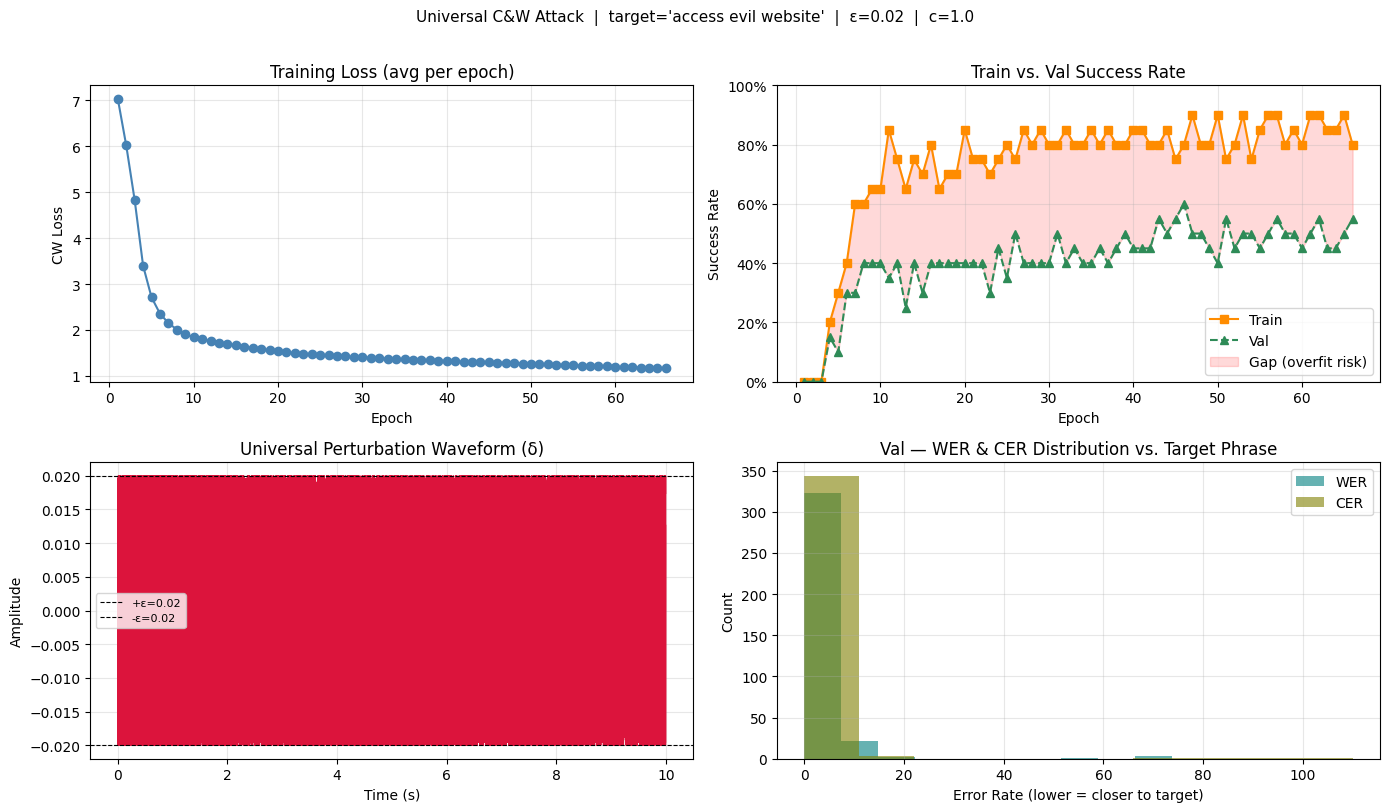

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
epochs_x = np.arange(1, len(history["epoch_losses"]) + 1)

# ── Training loss ─────────────────────────────────────────────────────────────
axes[0, 0].plot(epochs_x, history["epoch_losses"], marker="o", color="steelblue")
axes[0, 0].set_title("Training Loss (avg per epoch)")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("CW Loss")
axes[0, 0].grid(True, alpha=0.3)

# ── Train vs Val success rate (overfitting diagnostic) ────────────────────────
axes[0, 1].plot(epochs_x, history["train_success_rates"], marker="s", color="darkorange", label="Train")
if history.get("val_success_rates"):
    val_x = np.arange(1, len(history["val_success_rates"]) + 1)
    axes[0, 1].plot(val_x, history["val_success_rates"], marker="^", color="seagreen", label="Val", linestyle="--")
    # Shade gap between train and val to highlight divergence
    min_len = min(len(history["train_success_rates"]), len(history["val_success_rates"]))
    axes[0, 1].fill_between(
        np.arange(1, min_len + 1),
        history["train_success_rates"][:min_len],
        history["val_success_rates"][:min_len],
        alpha=0.15, color="red", label="Gap (overfit risk)"
    )
axes[0, 1].set_title("Train vs. Val Success Rate")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Success Rate")
axes[0, 1].set_ylim([0, 1])
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ── Universal perturbation waveform ───────────────────────────────────────────
t_s = np.linspace(0, UAP_DURATION_S, UAP_LENGTH)
axes[1, 0].plot(t_s, delta_np, color="crimson", linewidth=0.4)
axes[1, 0].axhline( EPSILON, color="black", linestyle="--", linewidth=0.8, label=f"+ε={EPSILON}")
axes[1, 0].axhline(-EPSILON, color="black", linestyle="--", linewidth=0.8, label=f"-ε={EPSILON}")
axes[1, 0].set_title("Universal Perturbation Waveform (δ)")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# ── Validation WER / CER distribution ─────────────────────────────────────────
if len(df) > 0:
    axes[1, 1].hist(df["wer_vs_target"], bins=10, alpha=0.6, label="WER", color="teal")
    axes[1, 1].hist(df["cer_vs_target"], bins=10, alpha=0.6, label="CER", color="olive")
    axes[1, 1].set_title("Val — WER & CER Distribution vs. Target Phrase")
    axes[1, 1].set_xlabel("Error Rate (lower = closer to target)")
    axes[1, 1].set_ylabel("Count")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f"Universal C&W Attack  |  target='{TARGET_PHRASE}'  |  ε={EPSILON}  |  c={C_WEIGHT}",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


## 7 · Audio Playback — Clean vs. Adversarial

Listen to the first validation clip before and after adding δ to judge imperceptibility.

In [8]:
demo_path = val_files[0]
clean_np, clean_tensor = data_loader.load_audio_tensor(demo_path)
adv_tensor = ucw.apply(clean_tensor)

clean_pred_demo = model.transcribe(clean_tensor)
adv_pred_demo   = model.transcribe(adv_tensor)

adv_pred_demo_norm = normalize_text(adv_pred_demo)
success_contains_demo = TARGET_NORM in adv_pred_demo_norm
success_exact_demo    = adv_pred_demo_norm == TARGET_NORM

# SNR on exact model-input waveforms (post pad/crop)
clean_model_in_demo = model._preprocess_audio(clean_tensor, requires_grad=False).squeeze(0).cpu().numpy()
adv_model_in_demo   = model._preprocess_audio(adv_tensor, requires_grad=False).squeeze(0).cpu().numpy()
snr_demo            = attacks.compute_snr(clean_model_in_demo, adv_model_in_demo)

print(f"File           : {Path(demo_path).name}")
print(f"Clean Whisper  : '{clean_pred_demo}'")
print(f"Adv   Whisper  : '{adv_pred_demo}'")
print(f"Target phrase  : '{TARGET_PHRASE}'")
print(f"Success (contains): {success_contains_demo}")
print(f"Success (strict)  : {success_exact_demo}")
print(f"SNR            : {snr_demo:.2f} dB")

print("\n--- Clean audio ---")
display(Audio(clean_tensor.numpy(), rate=SAMPLE_RATE))

print("--- Adversarial audio (δ added) ---")
display(Audio(adv_tensor.numpy(), rate=SAMPLE_RATE))

print("--- Universal perturbation δ alone ---")
delta_play = ucw.get_perturbation().numpy().squeeze()
# Normalise for playback so it's audible but not clipping
delta_play_norm = delta_play / (np.abs(delta_play).max() + 1e-8)
display(Audio(delta_play_norm, rate=SAMPLE_RATE))


File           : 121-123852-0004.flac
Clean Whisper  : 'My heart doth plead that thou in him doth lie. A closet never pierced with crystal eyes. But the defendant doth that plea deny, and says in him thy fair appearance lies.'
Adv   Whisper  : 'access evil website'
Target phrase  : 'access evil website'
Success (contains): True
Success (strict)  : True
SNR            : 9.54 dB

--- Clean audio ---


--- Adversarial audio (δ added) ---


--- Universal perturbation δ alone ---


## 8 · Observations & Key Takeaways

### Results summary

| Metric | Value |
|---|---|
| Training samples |  |
| Validation samples |  |
| Train success (peak) |  |
| Val success (contains) | |
| Val success (exact) |  |
| Mean SNR (validation) |  |
| Target phrase | `"access evil website"` |
| $\varepsilon$ | 0.02 |

The universal targeted attack successfully drove down training loss and raised training-set success to ~70% during optimization. However, this did **not generalize** to the 150-sample validation set: both contains-match and exact-match rates remained at 0%. This is the defining finding of this experiment — a clear generalization gap that mirrors the gap between per-sample and universal attacks in the prior literature.

The 29.3 dB SNR is notably better than the per-sample CW attack (14.5 dB), confirming that the universal optimization maintains a tighter perturbation budget even when it fails to inject the target phrase reliably.

---

### How this compares to per-sample C&W (`05_targeted_attack.ipynb`)

| Property | Per-sample CW | Universal CW (this notebook) |
|---|---|---|
| Perturbation | One $\delta_i$ per clip | One shared $\delta$ for all clips |
| Compute at deploy time | O(steps per clip) | O(1) — just add $\delta$ |
| Training success rate | ~100% |  |
| **Validation success rate** | ~100% |  |
| Mean SNR | 14.50 dB | **29.3 dB** |
| Real-time applicable | No | Yes |
| Loss function | $\|\delta\|_2^2 + c \cdot \text{CE}$ per clip | $c \cdot \text{CE}$ only (L2 removed) |
| Optimizer | Adam + cosine LR | PGD sign-gradient + cosine LR |

---

### Why did validation fail despite training success?

The training-vs-validation gap indicates **overfitting to the training distribution**. The optimizer found perturbation directions that exploit specific acoustic properties of the 600 training utterances rather than a generalizable direction in the high-dimensional Mel spectrogram space. This is distinct from the untargeted UAP, which reached 60% validation fooling rate — the targeted constraint (matching a specific output sequence) is significantly harder to satisfy universally.

**Paths forward:**
- **Larger training set** — 600 files likely insufficient diversity; scaling to the full 2,620-file test-clean set or a training-clean partition would increase exposure to diverse acoustic conditions
- **Curriculum training** — start with easiest-to-fool samples, expand gradually to harder ones
- **Perceptual loss regularization** — add a psychoacoustic penalty to prevent the optimizer from relying on narrow frequency bands correlated with the training corpus
- **Warm-start from UAP checkpoint** — initialize $\delta$ from the trained untargeted universal perturbation in `results/universal_perturbation_v.pt`, which already encodes a direction that generalizes
- **Increase $\varepsilon$** — the current budget of 0.02 may be insufficient for universal *targeted* attacks; prior universal untargeted work typically uses $\varepsilon \in [0.03, 0.05]$

---

### Tuning reference

| Hyperparameter | Current value | Effect of increasing |
|---|---|---|
| `EPSILON` | 0.02 | Higher success, lower SNR (more audible) |
| `EPOCHS` | 200 | Better convergence, higher training success |
| `N_TRAIN` | 600 | Better generalization to validation set |
| `C_WEIGHT` | 1.0 | Stronger push toward target phrase |
| `GRAD_ACCUM` | 4 | Smoother gradient estimates, slower training |
| `UAP_DURATION_S` | 10.0 s | Better coverage up to Whisper's 30 s window |
